#  Machine Learning Model Development

The objective of this phase is to develop and evaluate machine learning models for predicting the Secondary Drop Out Rate - Overall using dropout information from the Primary and Upper Primary educational levels. The workflow includes data preparation, feature selection, model training, prediction and performance evaluation.

In [ ]:
## 1. Importing Required Libraries
# The required Python libraries are imported for data manipulation, visualization, machine learning and model evaluation.
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ML
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [ ]:
## 2. Loading the Dataset
# The cleaned dataset containing statewise dropout rates was loaded into a Pandas DataFrame. This dataset will be used for training and evaluating the machine learning models.
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('level_cleaned.csv')
df.columns = df.columns.str.strip() # Clean column names by stripping whitespace
df.head()

,State/UT,Primary Drop Out Rate - Boys,Primary Drop Out Rate - Girls,Primary Drop Out Rate - Overall,Upper Primary Drop Out Rate - Boys,Upper Primary Drop Out Rate - Girls,Upper Primary Drop Out Rate - Overall,Secondary Drop Out Rate - Boys,Secondary Drop Out Rate - Girls,Secondary Drop Out Rate - Overall
0,Andaman And Nicobar Islands,0.2,0.7,0.4,0.9,1.0,1.0,6.0,3.9,5.0
1,Andhra Pradesh,0.0,0.0,0.0,1.7,1.5,1.6,17.5,15.0,16.3
2,Arunachal Pradesh,9.3,9.2,9.3,4.8,8.4,6.7,11.2,12.3,11.7
3,Assam,6.8,5.2,6.0,10.1,7.6,8.8,19.8,20.7,20.3
4,Bihar,0.0,0.0,0.0,4.0,5.2,4.6,19.5,21.4,20.5


In [ ]:
## 3. Understanding the Dataset
# Before building a model, it is important to understand the structure of the dataset. The number of observations, available variables, data types and summary statistics are examined.
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   State/UT                               36 non-null     object 
 1   Primary Drop Out Rate - Boys           36 non-null     float64
 2   Primary Drop Out Rate - Girls          36 non-null     float64
 3   Primary Drop Out Rate - Overall        36 non-null     float64
 4   Upper Primary Drop Out Rate - Boys     36 non-null     float64
 5   Upper Primary Drop Out Rate - Girls    36 non-null     float64
 6   Upper Primary Drop Out Rate - Overall  36 non-null     float64
 7   Secondary Drop Out Rate - Boys         36 non-null     float64
 8   Secondary Drop Out Rate - Girls        36 non-null     float64
 9   Secondary Drop Out Rate - Overall      36 non-null     float64
dtypes: float64(9), object(1)
memory usage: 2.9+ KB


,Primary Drop Out Rate - Boys,Primary Drop Out Rate - Girls,Primary Drop Out Rate - Overall,Upper Primary Drop Out Rate - Boys,Upper Primary Drop Out Rate - Girls,Upper Primary Drop Out Rate - Overall,Secondary Drop Out Rate - Boys,Secondary Drop Out Rate - Girls,Secondary Drop Out Rate - Overall
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,2.716667,2.291667,2.513889,3.258333,3.002778,3.130556,11.219444,9.605556,10.425000
std,3.676683,3.284020,3.467000,3.141826,2.890525,2.945391,6.811747,6.509595,6.600189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.525000,0.150000,0.500000,6.225000,4.475000,5.375000
50%,1.000000,0.550000,0.800000,2.900000,2.250000,2.700000,10.550000,8.650000,9.600000
75%,3.825000,3.725000,3.775000,4.650000,4.825000,4.525000,16.525000,13.500000,15.100000
max,13.500000,13.000000,13.300000,12.000000,9.400000,10.600000,29.200000,25.200000,27.300000


In [1]:
## 4. Feature Selection
# ML  models require input variables (features) and an output variable (target). In this project, the Primary and Upper Primary dropout rates are used as predictor variables, while the Secondary Drop Out Rate - Overall is selected as the target variable.
X = df[ [
        "Primary Drop Out Rate - Boys",
        "Primary Drop Out Rate - Girls",
        "Primary Drop Out Rate - Overall",
        "Upper Primary Drop Out Rate - Boys",
        "Upper Primary Drop Out Rate - Girls",
        "Upper Primary Drop Out Rate - Overall"] ]
# Target (y)
y = df["Secondary Drop Out Rate - Overall"]

NameError: name 'df' is not defined

In [ ]:
print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
   Primary Drop Out Rate - Boys  Primary Drop Out Rate - Girls  \
0                           0.2                            0.7   
1                           0.0                            0.0   
2                           9.3                            9.2   
3                           6.8                            5.2   
4                           0.0                            0.0   

   Primary Drop Out Rate - Overall  Upper Primary Drop Out Rate - Boys  \
0                              0.4                                 0.9   
1                              0.0                                 1.7   
2                              9.3                                 4.8   
3                              6.0                                10.1   
4                              0.0                                 4.0   

   Upper Primary Drop Out Rate - Girls  Upper Primary Drop Out Rate - Overall  
0                                  1.0                              

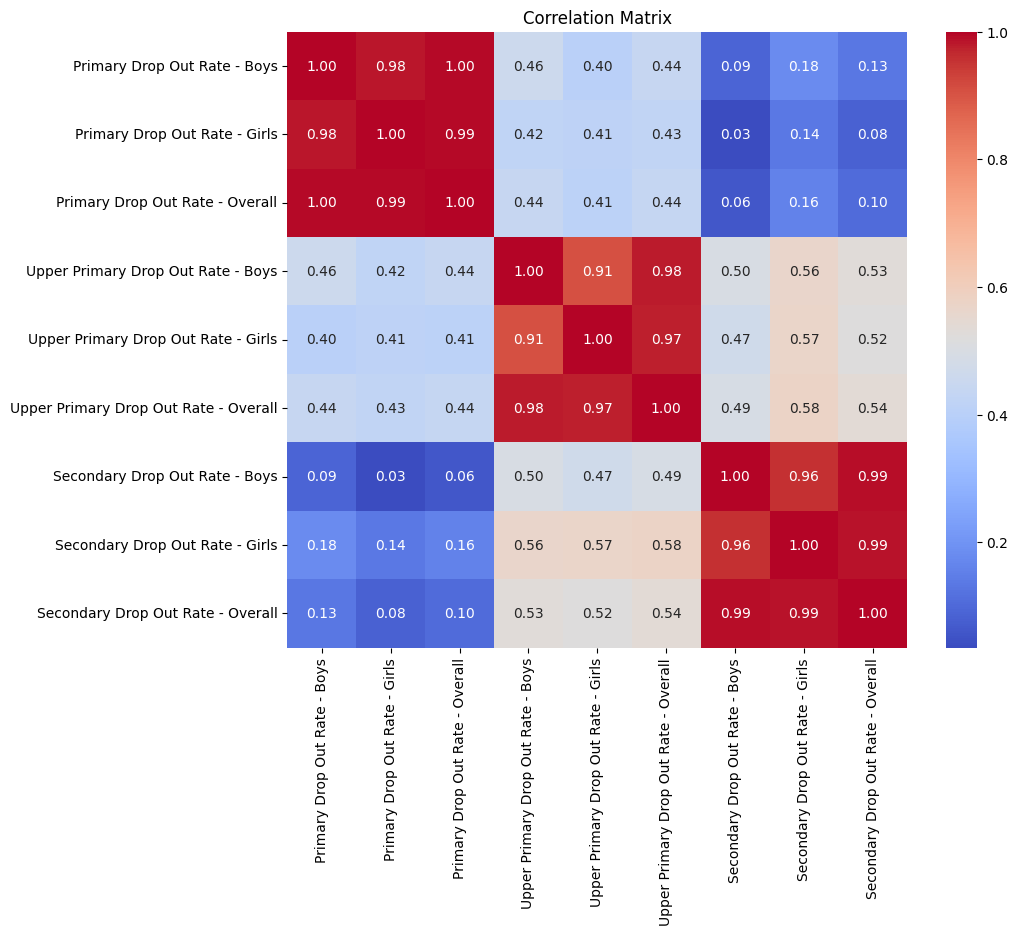

In [ ]:
## 5. Correlation matrix
# A correlation matrix is generated to study the relationships among the variables. This helps identify highly correlated features and provides an understanding of how strongly each predictor is related to the target variable.
corr = df.corr(numeric_only=True)
corr
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
## 6. Splitting the Dataset
# The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen observations.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)


## 7. Linear Regression
# Linear Regression is selected as the first machine learning model because it is simple, interpretable and suitable for predicting continuous numerical values. The model learns the relationship between the selected predictor variables and the secondary dropout rate.
model = LinearRegression()
# Training model
model.fit(X_train, y_train)
print("Model trained successfully!")

Training Features : (28, 6)
Testing Features  : (8, 6)
Training Target   : (28,)
Testing Target    : (8,)
Model trained successfully!


In [ ]:
## 8. Making Predictions
# After training, the Linear Regression model is used to predict the secondary dropout rate for the testing dataset. The predicted values are then compared with the actual observations.
# Prediction on test data
y_pred = model.predict(X_test)
# Display predictions
print(y_pred)
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison
print(comparison.head(10))

[ 5.68185272  7.0716886   2.39338523  7.04477053  7.04477053 10.96930361
 -0.94013374  8.0909162 ]
    Actual  Predicted
35    18.0   5.681853
13     6.0   7.071689
26     6.3   2.393385
30     4.5   7.044771
16     5.5   7.044771
31    13.7  10.969304
21     1.3  -0.940134
12     1.5   8.090916


In [ ]:
## 9. Evaluating the Linear Regression Model
# The performance of the model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² Score. These metrics indicate how accurately the model predicts the target variable.
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
# Root Mean Squared Error
rmse = np.sqrt(mse)
# R-squared Score
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R-squared Score :", r2)

Mean Absolute Error : 4.118467256421573
Mean Squared Error  : 29.115519897309113
Root Mean Squared Error : 5.395879900193212
R-squared Score : 0.02354255395961713


In [ ]:
# Display coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients
print(coefficients)
print("Intercept:", model.intercept_)

                                 Feature  Coefficient
0           Primary Drop Out Rate - Boys    41.539065
1          Primary Drop Out Rate - Girls    32.209257
2        Primary Drop Out Rate - Overall   -74.823758
3     Upper Primary Drop Out Rate - Boys    -3.827474
4    Upper Primary Drop Out Rate - Girls    -1.049402
5  Upper Primary Drop Out Rate - Overall     6.445552
Intercept: 7.044770534150448


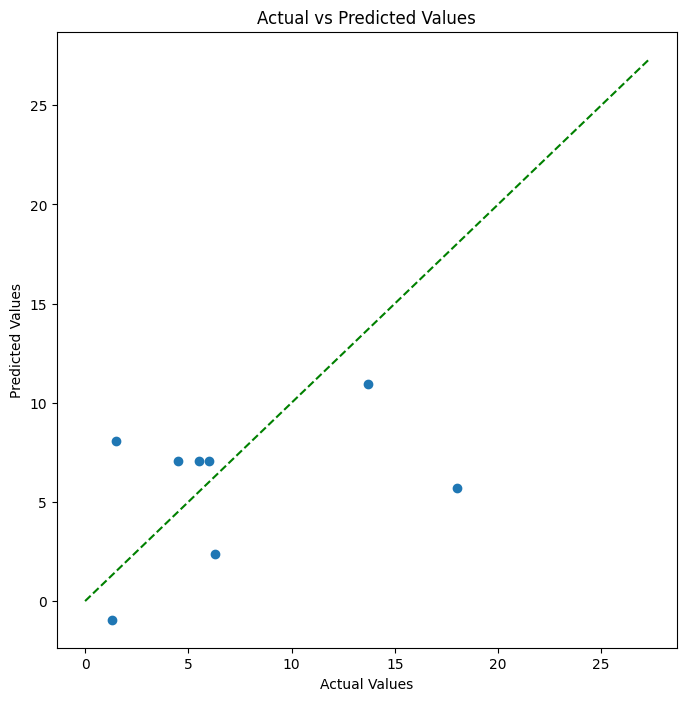

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color='green',
    linestyle='--'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [ ]:
## 10. Decision Tree Regression
# A Decision Tree Regressor is trained using the same training dataset. Unlike Linear Regression, Decision Trees can capture nonlinear relationships by splitting the data into smaller decision regions.
from sklearn.tree import DecisionTreeRegressor
# Create model
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=3
)
# Train model
tree_model.fit(X_train, y_train)
print("Decision Tree trained successfully!")
tree_pred = tree_model.predict(X_test)
comparison_tree = pd.DataFrame({
    "Actual": y_test,
    "Predicted": tree_pred
})
comparison_tree
print(comparison_tree.head(10))
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)
print("MAE :", tree_mae)
print("MSE :", tree_mse)
print("RMSE:", tree_rmse)
print("R2  :", tree_r2)

Decision Tree trained successfully!
    Actual  Predicted
35    18.0       8.40
13     6.0       8.98
26     6.3       8.98
30     4.5       5.70
16     5.5       5.70
31    13.7       8.98
21     1.3      18.75
12     1.5       5.70
MAE : 5.37875
MSE : 56.7654625
RMSE: 7.534285798932769
R2  : -0.9037633101366649


In [ ]:
# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})
# Sort from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
4,Upper Primary Drop Out Rate - Girls,0.881713
5,Upper Primary Drop Out Rate - Overall,0.091429
1,Primary Drop Out Rate - Girls,0.014000
0,Primary Drop Out Rate - Boys,0.012857
3,Upper Primary Drop Out Rate - Boys,0.000000
2,Primary Drop Out Rate - Overall,0.000000


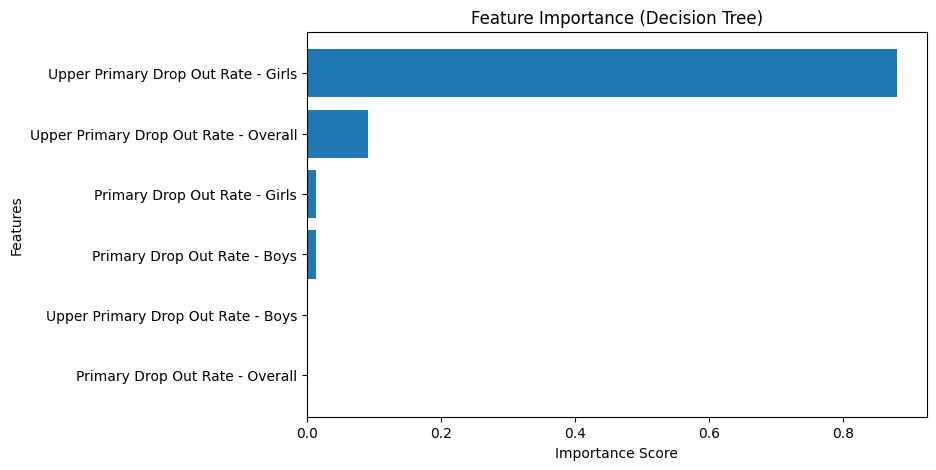

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance (Decision Tree)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
## 11. Comparing the Models
# The performance of the Linear Regression and Decision Tree models is compared using the same evaluation metrics. This comparison helps identify the model that performs better on the available dataset.
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [mae, tree_mae],
    "RMSE": [rmse, tree_rmse],
    "R2 Score": [r2, tree_r2]
})
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.118467,5.395880,0.023543
1,Decision Tree,5.378750,7.534286,-0.903763


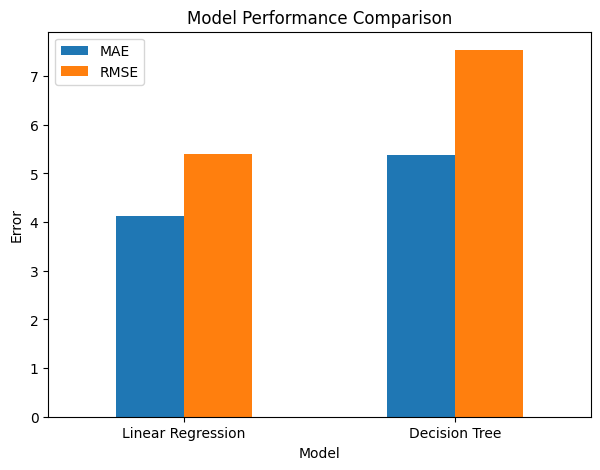

In [ ]:
results.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(7,5)
)
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

In [ ]:
## 12. Interpretation of Results
# The Linear Regression model performed better than the Decision Tree model on the available dataset. Although the prediction accuracy was limited, the results demonstrate that upper primary dropout rates have a stronger relationship with secondary dropout than primary dropout rates.
# The relatively low predictive performance can be attributed to the small number of observations and the limited set of predictor variables. Additional socioeconomic and educational indicators could improve the predictive capability of future models.

# Conclusion

In this week's work, two regression models were developed to predict the Secondary Drop Out Rate - Overall using state level dropout statistics.

Among the two models,  Linear Regression achieved better performance than the Decision Tree Regressor. However, both models showed limited predictive accuracy due to the small dataset and the moderate correlation between the predictor variables and the target variable.

This exercise provided practical experience in the complete machine learning workflow, including feature selection, train test splitting, model development, prediction, evaluation and interpretation of results.